In [1]:
#LIBRARY 
import sys, os

import time
import numpy as np
from typing import Optional
from scipy.stats import norm
from scipy.optimize import linprog
from contextlib import redirect_stdout
# for MILP with cutting planes
import pulp
from dataclasses import dataclass

import matplotlib.pyplot as plt



In [2]:
# CODE TO DEFINE FUNCTIONS FOR COMPUTING THINGS 

# ── Time constants ──────────────────────────────────────────────
TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY
DT = 1.0 / STEPS_PER_YEAR  # one step in years

SIGMA = 2.51   # 251% annualized vol
S0 = 50.0
N_PATHS = 100  # for stable estimates (remember only 100 paths score you, but use more to estimate fairly)

def weeks_to_years(weeks):
    return (weeks * 5) / TRADING_DAYS_PER_YEAR

def steps_for_weeks(weeks):
    return int(round(weeks * 5 * STEPS_PER_DAY))

# ── Simulate full paths ──────────────────────────────────────────
def simulate_paths(S0, sigma, n_steps, n_paths):
    """
    Returns array of shape (n_paths, n_steps+1)
    S[i, t] = price of path i at step t
    """
    Z = np.random.randn(n_paths, n_steps)
    log_increments = (-0.5 * sigma**2 * DT) + sigma * np.sqrt(DT) * Z
    log_S = np.concatenate([
        np.zeros((n_paths, 1)),
        np.cumsum(log_increments, axis=1)
    ], axis=1)
    return S0 * np.exp(log_S)

# ── Black-Scholes (needed for Chooser) ──────────────────────────
def bs_call(S, K, T, sigma):
    if T <= 0:
        return np.maximum(S - K, 0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_put(S, K, T, sigma):
    if T <= 0:
        return np.maximum(K - S, 0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * norm.cdf(-d2) - S * norm.cdf(-d1)

# ── Payoff functions (vectorized over paths) ─────────────────────
def payoff_vanilla_call(paths, K, expiry_steps):
    ST = paths[:, expiry_steps]
    return np.maximum(ST - K, 0)

def payoff_vanilla_put(paths, K, expiry_steps):
    ST = paths[:, expiry_steps]
    return np.maximum(K - ST, 0)

def payoff_chooser(paths, K, decision_steps, expiry_steps):
    """
    At decision_steps: holder picks call or put for remaining life.
    Remaining time in years from decision point to expiry.
    """
    S_decision = paths[:, decision_steps]
    T_remaining = (expiry_steps - decision_steps) * DT
    call_val = bs_call(S_decision, K, T_remaining, SIGMA)
    put_val  = bs_put(S_decision,  K, T_remaining, SIGMA)
    return np.maximum(call_val, put_val)

def payoff_binary_put(paths, K, expiry_steps, payout):
    ST = paths[:, expiry_steps]
    return np.where(ST < K, payout, 0.0)

def payoff_knockout_put(paths, K, barrier, expiry_steps):
    """
    Standard put UNLESS any discrete step ever goes below barrier.
    """
    ST = paths[:, expiry_steps]
    # minimum price over all steps up to expiry (discrete monitoring only)
    min_S = np.min(paths[:, :expiry_steps+1], axis=1)
    knocked_out = min_S <= barrier
    put_payoff = np.maximum(K - ST, 0)
    return np.where(knocked_out, 0.0, put_payoff)

# ── Fair value and edge ──────────────────────────────────────────
def fair_value(payoffs):
    return np.mean(payoffs)

def edge_buy(payoffs, ask):
    return fair_value(payoffs) - ask

def edge_sell(payoffs, bid):
    return bid - fair_value(payoffs)

In [3]:

# ── Base class ───────────────────────────────────────────────────
@dataclass
class Instrument:
    """
    Every instrument has:
    - a name (for reference)
    - a bid and ask (market prices)
    - a max volume (position limit)
    All subclasses must implement payoff(paths) -> np.ndarray
    """
    name: str
    bid: float
    ask: float
    max_volume: int

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def fair_value(self, paths: np.ndarray) -> float:
        return float(np.mean(self.payoff(paths)))

    def edge_buy(self, paths: np.ndarray) -> float:
        return self.fair_value(paths) - self.ask

    def edge_sell(self, paths: np.ndarray) -> float:
        return self.bid - self.fair_value(paths)

    def best_edge(self, paths: np.ndarray) -> tuple[str, float]:
        """Returns ('buy', edge) or ('sell', edge), whichever is larger."""
        eb = self.edge_buy(paths)
        es = self.edge_sell(paths)
        if eb >= es:
            return ('buy', eb)
        else:
            return ('sell', es)

In [4]:
# ── Underlying ───────────────────────────────────────────────────
@dataclass
class Underlying(Instrument):
    """
    Payoff = S_T - S_0
    Used purely for delta hedging, edge should be ~0 by construction.
    """
    S0: float = 50.0

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        # paths[:, -1] is the terminal price
        # but payoff is the P&L of holding one unit: S_T - S_0
        return paths[:, -1]

In [5]:
# ── Vanilla Call ─────────────────────────────────────────────────
@dataclass
class VanillaCall(Instrument):
    """
    Payoff = max(S_T - K, 0)
    """
    K: float           # strike
    expiry_steps: int  # how many steps until expiry

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        ST = paths[:, self.expiry_steps]
        return np.maximum(ST - self.K, 0)

In [6]:
# ── Vanilla Put ──────────────────────────────────────────────────
@dataclass
class VanillaPut(Instrument):
    """
    Payoff = max(K - S_T, 0)
    """
    K: float
    expiry_steps: int

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        ST = paths[:, self.expiry_steps]
        return np.maximum(self.K - ST, 0)

In [7]:
# ── Chooser Option ───────────────────────────────────────────────
@dataclass
class ChooserOption(Instrument):
    """
    At decision_steps (week 2), holder picks call or put.
    Picks whichever has higher BS value for the remaining life.
    Then expires at expiry_steps (week 3).
    """
    K: float
    decision_steps: int  # step 40 (2 weeks)
    expiry_steps: int    # step 60 (3 weeks)

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        S_decision = paths[:, self.decision_steps]
        T_remaining = (self.expiry_steps - self.decision_steps) * DT

        call_val = bs_call(S_decision, self.K, T_remaining, SIGMA)
        put_val  = bs_put(S_decision,  self.K, T_remaining, SIGMA)

        # holder picks the more valuable side
        return np.maximum(call_val, put_val)

In [8]:
# ── Binary Put ───────────────────────────────────────────────────
@dataclass
class BinaryPut(Instrument):
    """
    Pays fixed `payout` if S_T < K, else 0.
    """
    K: float
    expiry_steps: int
    payout: float  # fixed cash amount paid if in the money

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        ST = paths[:, self.expiry_steps]
        return np.where(ST < self.K, self.payout, 0.0)

In [9]:
# ── Knock-Out Put ────────────────────────────────────────────────
@dataclass
class KnockOutPut(Instrument):
    """
    Standard put UNLESS the price ever touches or goes below
    the barrier at any discrete monitoring point.
    If knocked out -> pays 0.
    """
    K: float
    barrier: float
    expiry_steps: int

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        ST = paths[:, self.expiry_steps]

        # check minimum over all discrete steps up to expiry
        min_S = np.min(paths[:, :self.expiry_steps + 1], axis=1)
        knocked_out = min_S <= self.barrier

        put_payoff = np.maximum(self.K - ST, 0)
        return np.where(knocked_out, 0.0, put_payoff)

In [10]:
T21 = steps_for_weeks(3)  # 60 steps
T14 = steps_for_weeks(2)  # 40 steps

instruments = [
    # ── Underlying ──────────────────────────────────────────
    Underlying(
        name="AC",
        bid=49.975, ask=50.025,
        max_volume=200,
        S0=50.0
    ),

    # ── Vanilla Puts T+21 ───────────────────────────────────
    VanillaPut(name="AC_50_P", bid=12.00, ask=12.05, max_volume=50, K=50, expiry_steps=T21),
    VanillaPut(name="AC_35_P", bid=4.33,  ask=4.35,  max_volume=50, K=35, expiry_steps=T21),
    VanillaPut(name="AC_40_P", bid=6.50,  ask=6.55,  max_volume=50, K=40, expiry_steps=T21),
    VanillaPut(name="AC_45_P", bid=9.05,  ask=9.10,  max_volume=50, K=45, expiry_steps=T21),

    # ── Vanilla Calls T+21 ──────────────────────────────────
    VanillaCall(name="AC_50_C", bid=12.00, ask=12.05, max_volume=50, K=50, expiry_steps=T21),
    VanillaCall(name="AC_60_C", bid=8.80,  ask=8.85,  max_volume=50, K=60, expiry_steps=T21),

    # ── Vanilla T+14 ────────────────────────────────────────
    VanillaPut( name="AC_50_P_2", bid=9.70, ask=9.75, max_volume=50, K=50, expiry_steps=T14),
    VanillaCall(name="AC_50_C_2", bid=9.70, ask=9.75, max_volume=50, K=50, expiry_steps=T14),

    # ── Chooser ─────────────────────────────────────────────
    ChooserOption(
        name="AC_50_CO",
        bid=22.2, ask=22.3,
        max_volume=50,
        K=50,
        decision_steps=T14,   # 40 steps: choice at week 2
        expiry_steps=T21      # 60 steps: expires at week 3
    ),

    # ── Binary Put ──────────────────────────────────────────
    BinaryPut(
        name="AC_40_BP",
        bid=5.0, ask=5.1,
        max_volume=50,
        K=40,
        expiry_steps=T21,
        payout=10.0           # pays 10 XIRECs if S_T < 40
    ),

    # ── Knock-Out Put ────────────────────────────────────────
    KnockOutPut(
        name="AC_45_KO",
        bid=0.15, ask=0.175,
        max_volume=500,
        K=45,
        barrier=35.0,
        expiry_steps=T21
    ),
]

In [11]:
# ════════════════════════════════════════════════════════════════
# STEP 1: RUN SIMULATION
# ════════════════════════════════════════════════════════════════

np.random.seed(42)  # reproducibility

T21 = steps_for_weeks(3)  # 60 steps
T14 = steps_for_weeks(2)  # 40 steps

# Simulate enough paths for stable estimates
# We use 100k paths to estimate fair values accurately
# The actual scoring uses 100 paths, but we need stable estimates
paths = simulate_paths(S0=50.0, sigma=SIGMA, n_steps=T21, n_paths=100_000)

print(f"Paths shape: {paths.shape}")  # (100000, 61)
print(f"E[S_T21]: {paths[:, T21].mean():.4f}")  # should be ~50 (martingale)
print(f"E[S_T14]: {paths[:, T14].mean():.4f}")  # should be ~50

Paths shape: (100000, 61)
E[S_T21]: 49.8485
E[S_T14]: 49.8793


In [12]:
# ════════════════════════════════════════════════════════════════
# STEP 2: COMPUTE FAIR VALUES AND EDGES FOR EVERY INSTRUMENT
# ════════════════════════════════════════════════════════════════

def compute_all_edges(instruments, paths):
    """
    For each instrument, compute:
    - fair_value: E[payoff]
    - edge_buy:   E[payoff] - ask  (positive = underpriced, buy it)
    - edge_sell:  bid - E[payoff]  (positive = overpriced, sell it)
    - best_action: 'buy' or 'sell' and the corresponding edge
    
    Returns a list of dicts, one per instrument.
    """
    results = []
    for inst in instruments:
        fv = inst.fair_value(paths)
        eb = inst.edge_buy(paths)
        es = inst.edge_sell(paths)
        action, edge = inst.best_edge(paths)
        results.append({
            'name':       inst.name,
            'fair_value': fv,
            'ask':        inst.ask,
            'bid':        inst.bid,
            'edge_buy':   eb,
            'edge_sell':  es,
            'best_action': action,
            'best_edge':   edge,
            'max_volume':  inst.max_volume,
        })
    return results

In [13]:
# ════════════════════════════════════════════════════════════════
# STEP 3: COMPUTE DELTA FOR EVERY INSTRUMENT
# ════════════════════════════════════════════════════════════════

def compute_delta(inst, paths, dS=0.5):
    """
    Numerical delta via finite difference.
    
    Delta = dE[payoff] / dS_0
    
    We approximate this by bumping S_0 up and down by dS,
    rescaling the entire path proportionally, and recomputing
    the fair value. The ratio of the change in fair value to
    the change in S_0 is the delta.
    
    Why rescale the whole path? Because every point on the path
    is proportional to S_0 in GBM. Multiplying all prices by
    (S0 + dS)/S0 is equivalent to starting from S0 + dS.
    
    dS=0.5 means we bump by 1% of S0=50, which is a reasonable
    finite difference step — small enough to be accurate,
    large enough to avoid numerical noise.
    """
    S0 = 50.0

    # bump up: scale all paths by (S0+dS)/S0
    paths_up   = paths * (S0 + dS) / S0
    paths_down = paths * (S0 - dS) / S0

    fv_up   = float(np.mean(inst.payoff(paths_up)))
    fv_down = float(np.mean(inst.payoff(paths_down)))

    delta = (fv_up - fv_down) / (2 * dS)
    return delta


def compute_all_deltas(instruments, paths):
    return {inst.name: compute_delta(inst, paths) for inst in instruments}



In [14]:
# ════════════════════════════════════════════════════════════════
# STEP 4: THE INTEGER OPTIMIZATION (MILP with PuLP)
# ════════════════════════════════════════════════════════════════

"""
Why PuLP?
PuLP is a Python LP/MILP modelling library that internally uses
the CBC solver, which implements branch-and-bound with cutting planes
(Gomory cuts, knapsack cuts, etc.). This is exactly the cutting plane
method we want, without having to implement it from scratch.

The cutting plane idea:
1. Solve the LP relaxation (q_i continuous in [-q_bar_i, q_bar_i])
2. If solution is already integer -> done
3. Find a violated integrality constraint
4. Add a 'cut' — a new linear constraint that:
   - excludes the fractional solution
   - does NOT exclude any integer feasible solution
5. Repeat until all variables are integer

PuLP + CBC does this automatically when you declare variables as integers.
"""

def solve_milp(instruments, paths, delta_neutral=True, delta_tolerance=5.0):
    """
    Solves the integer optimization problem:
    
    max  sum_i  q_i * alpha_i(sign(q_i))
    s.t. q_i in Z (integer)
         -q_bar_i <= q_i <= q_bar_i
         |sum_i q_i * delta_i| <= delta_tolerance  (if delta_neutral=True)
    
    The sign-dependent edge is handled by splitting each q_i
    into two non-negative integer variables:
        q_i = q_i_plus - q_i_minus
        q_i_plus  >= 0  (long position)
        q_i_minus >= 0  (short position)
    
    This linearizes the sign-dependent objective.
    We add the constraint q_i_plus * q_i_minus = 0 implicitly
    by the optimization — since both contribute positively to
    the objective only when one is zero, the solver will never
    set both simultaneously (they'd cancel out).
    """

    # -- compute edges and deltas --
    edge_results = compute_all_edges(instruments, paths)
    deltas       = compute_all_deltas(instruments, paths)

    # -- build the MILP model --
    model = pulp.LpProblem("MaxPnL", pulp.LpMaximize)

    # For each instrument i, create two non-negative integer variables:
    # q_plus[i]  = units bought  (long)
    # q_minus[i] = units sold    (short)
    q_plus  = {}
    q_minus = {}

    for r in edge_results:
        name = r['name']
        qbar = r['max_volume']

        # integer variables, bounded by volume limit
        q_plus[name]  = pulp.LpVariable(f"qp_{name}", lowBound=0, upBound=qbar, cat='Integer')
        q_minus[name] = pulp.LpVariable(f"qm_{name}", lowBound=0, upBound=qbar, cat='Integer')

    # -- objective --
    # For long positions: each unit bought earns edge_buy
    # For short positions: each unit sold earns edge_sell
    # We want to maximize total edge
    objective_terms = []
    for r in edge_results:
        name = r['name']
        eb   = r['edge_buy']
        es   = r['edge_sell']
        objective_terms.append(eb * q_plus[name])   # profit from buying
        objective_terms.append(es * q_minus[name])  # profit from selling

    model += pulp.lpSum(objective_terms), "TotalEdge"

    # -- delta neutrality constraint --
    # Net delta = sum_i (q_plus[i] - q_minus[i]) * delta_i
    # We want |net delta| <= tolerance
    if delta_neutral:
        net_delta = pulp.lpSum(
            deltas[r['name']] * (q_plus[r['name']] - q_minus[r['name']])
            for r in edge_results
        )
        # |net_delta| <= tolerance is two linear constraints:
        model += net_delta <=  delta_tolerance, "DeltaUpperBound"
        model += net_delta >= -delta_tolerance, "DeltaLowerBound"

    # -- solve --
    # CBC solver with cutting planes enabled (default in PuLP)
    solver = pulp.PULP_CBC_CMD(msg=1)  # msg=1 shows solver output
    model.solve(solver)

    # -- extract results --
    print(f"\nStatus: {pulp.LpStatus[model.status]}")
    print(f"Total Expected PnL (edge): {pulp.value(model.objective):.4f}\n")

    positions = {}
    for r in edge_results:
        name   = r['name']
        long_q  = int(round(pulp.value(q_plus[name])))
        short_q = int(round(pulp.value(q_minus[name])))
        net_q   = long_q - short_q

        if net_q != 0:
            action = 'BUY' if net_q > 0 else 'SELL'
            edge   = r['edge_buy'] if net_q > 0 else r['edge_sell']
            print(f"{name:15s} | {action:4s} {abs(net_q):4d} | "
                  f"FV={r['fair_value']:7.4f} | "
                  f"edge/unit={edge:+.4f} | "
                  f"total edge={edge*abs(net_q):+.4f} | "
                  f"delta={deltas[name]*net_q:+.4f}")
        positions[name] = net_q

    # print net delta
    net_delta_val = sum(deltas[name] * q for name, q in positions.items())
    print(f"\nNet portfolio delta: {net_delta_val:+.4f}")

    return positions, model


In [20]:
# ════════════════════════════════════════════════════════════════
# STEP 5: RUN EVERYTHING
# ════════════════════════════════════════════════════════════════

delta_tolerance = 10.00
delta_neutral = True

edge_results = compute_all_edges(instruments, paths)

print("=" * 60)
print("FAIR VALUES AND EDGES")
print("=" * 60)
for r in edge_results:
    print(f"{r['name']:15s} | FV={r['fair_value']:8.4f} | "
            f"edge_buy={r['edge_buy']:+7.4f} | "
            f"edge_sell={r['edge_sell']:+7.4f} | "
            f"best={r['best_action']:4s} ({r['best_edge']:+.4f})")

print("\n" + "=" * 60)
print("SOLVING MILP")
print("=" * 60)
positions, model = solve_milp(
    instruments,
    paths,
    delta_neutral=delta_neutral,
    delta_tolerance=delta_tolerance   # allow a small residual delta
)




FAIR VALUES AND EDGES
AC              | FV= 49.8485 | edge_buy=-0.1765 | edge_sell=+0.1265 | best=sell (+0.1265)
AC_50_P         | FV= 12.0429 | edge_buy=-0.0071 | edge_sell=-0.0429 | best=buy  (-0.0071)
AC_35_P         | FV=  4.3292 | edge_buy=-0.0208 | edge_sell=+0.0008 | best=sell (+0.0008)
AC_40_P         | FV=  6.5104 | edge_buy=-0.0396 | edge_sell=-0.0104 | best=sell (-0.0104)
AC_45_P         | FV=  9.0991 | edge_buy=-0.0009 | edge_sell=-0.0491 | best=buy  (-0.0009)
AC_50_C         | FV= 11.8914 | edge_buy=-0.1586 | edge_sell=+0.1086 | best=sell (+0.1086)
AC_60_C         | FV=  8.6616 | edge_buy=-0.1884 | edge_sell=+0.1384 | best=sell (+0.1384)
AC_50_P_2       | FV=  9.8548 | edge_buy=+0.1048 | edge_sell=-0.1548 | best=buy  (+0.1048)
AC_50_C_2       | FV=  9.7341 | edge_buy=-0.0159 | edge_sell=-0.0341 | best=buy  (-0.0159)
AC_50_CO        | FV= 21.7581 | edge_buy=-0.5419 | edge_sell=+0.4419 | best=sell (+0.4419)
AC_40_BP        | FV=  4.7900 | edge_buy=-0.3100 | edge_sell=+0.2100

In [21]:
# --- SUBMISSION SIMULATOR ---

def evaluate_portfolio(positions, instruments, eval_paths):
    """
    Evaluates the PnL of a fixed portfolio dictionary {name: q} on the given paths.
    Returns an array of shape (n_paths,) containing the total PnL for each path.
    """
    n_paths = eval_paths.shape[0]
    total_pnl = np.zeros(n_paths)
    
    inst_dict = {inst.name: inst for inst in instruments}
    
    for name, q in positions.items():
        if q == 0:
            continue
        inst = inst_dict[name]
        payoffs = inst.payoff(eval_paths)
        
        if q > 0:
            # Long position: pay ask upfront, receive payoff at expiry
            total_pnl += q * (payoffs - inst.ask)
        elif q < 0:
            # Short position: receive bid upfront, pay payoff at expiry
            total_pnl += abs(q) * (inst.bid - payoffs)
            
    return total_pnl


print(f"Solving for optimal portfolio with delta tolerance = {delta_tolerance}...")
# 2. Generate 100 brand new paths (simulating the Prosperity grader)
print("\nGenerating 100 fresh evaluation paths...")
T21 = steps_for_weeks(3)
new_paths = simulate_paths(S0=50.0, sigma=SIGMA, n_steps=T21, n_paths=100)

# 3. Evaluate the fixed portfolio on the 100 new paths
path_pnls = evaluate_portfolio(positions, instruments, new_paths)

# 4. Show the results
mean_pnl = np.mean(path_pnls)
std_pnl = np.std(path_pnls)

print("-" * 50)
print("SIMULATION RESULTS (100 Paths)")
print("-" * 50)
print(f"Mean PnL (Your Score): {mean_pnl:.4f}")
print(f"Std Dev (Risk):        {std_pnl:.4f}")
print(f"Min PnL (Worst Case):  {np.min(path_pnls):.4f}")
print(f"Max PnL (Best Case):   {np.max(path_pnls):.4f}")

# Optional: You can wrap this entirely in a loop if you want to test multiple 
# tolerances and see how the 100-path variance affects your final score!


Solving for optimal portfolio with delta tolerance = 10.0...

Generating 100 fresh evaluation paths...
--------------------------------------------------
SIMULATION RESULTS (100 Paths)
--------------------------------------------------
Mean PnL (Your Score): -287.1374
Std Dev (Risk):        2556.6766
Min PnL (Worst Case):  -13846.8578
Max PnL (Best Case):   4745.9625


Running 10000 simulated submissions (100 paths each)...


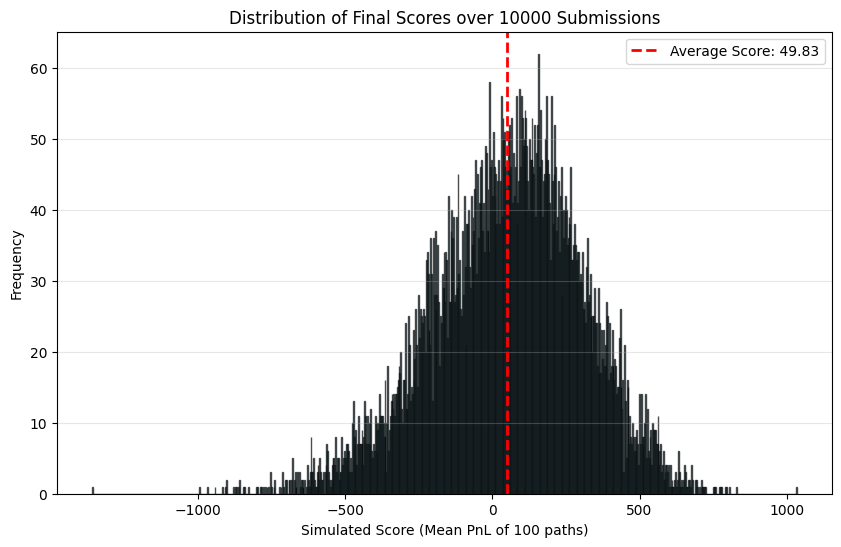

--------------------------------------------------
Worst simulated score: -1358.5041
Best simulated score:  1033.4093
Score Volatility:      254.6597
--------------------------------------------------


In [23]:

# 2. Run the submission simulator 100 times
n_simulations = 10_000
simulated_scores = []
T21 = steps_for_weeks(3)

print(f"Running {n_simulations} simulated submissions (100 paths each)...")
for i in range(n_simulations):
    # Generate 100 fresh paths (this is exactly what the grader does)
    new_paths = simulate_paths(S0=50.0, sigma=SIGMA, n_steps=T21, n_paths=100)
    
    # Evaluate the portfolio
    path_pnls = evaluate_portfolio(positions, instruments, new_paths)
    
    # The grader takes the mean of those 100 paths as your final score
    simulated_scores.append(np.mean(path_pnls))

# 3. Plot the distribution of the final scores
plt.figure(figsize=(10, 6))
plt.hist(simulated_scores, bins=800, color='skyblue', edgecolor='black', alpha=0.7)

# Add a line for the average
avg_score = np.mean(simulated_scores)
plt.axvline(avg_score, color='red', linestyle='dashed', linewidth=2, 
            label=f"Average Score: {avg_score:.2f}")

plt.title(f"Distribution of Final Scores over {n_simulations} Submissions")
plt.xlabel("Simulated Score (Mean PnL of 100 paths)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print summary stats
print("-" * 50)
print(f"Worst simulated score: {np.min(simulated_scores):.4f}")
print(f"Best simulated score:  {np.max(simulated_scores):.4f}")
print(f"Score Volatility:      {np.std(simulated_scores):.4f}")
print("-" * 50)
